In [1]:
from sklearn.datasets import load_breast_cancer

breast_cancer = load_breast_cancer()

In [2]:
X_unsupervised = breast_cancer.data
print(f"Shape of features for unsupervised learning: {X_unsupervised.shape}")

Shape of features for unsupervised learning: (569, 30)


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unsupervised)

print(f"Shape of scaled features: {X_scaled.shape}")
print(f"Mean of first feature after scaling: {X_scaled[:, 0].mean():.2f}")
print(f"Standard deviation of first feature after scaling: {X_scaled[:, 0].std():.2f}")

Shape of scaled features: (569, 30)
Mean of first feature after scaling: -0.00
Standard deviation of first feature after scaling: 1.00


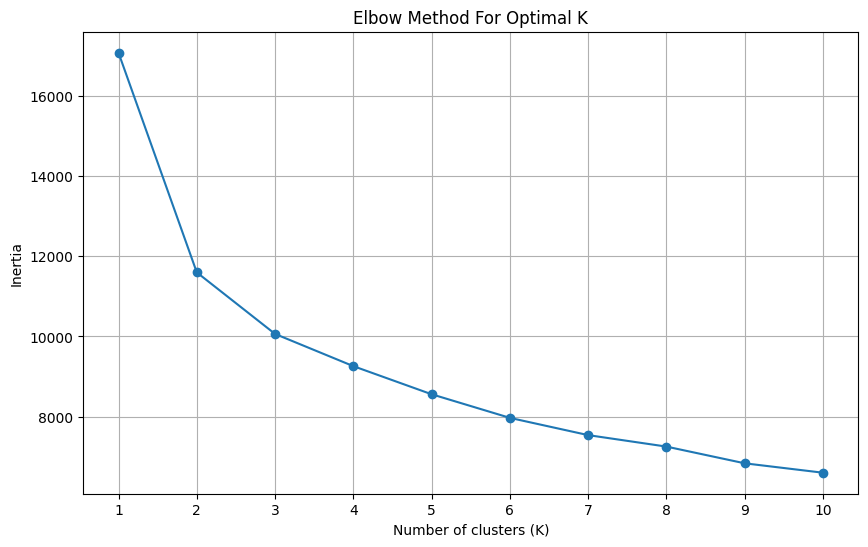

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_values = range(1, 11) # Test k from 1 to 10

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init='auto' or 10 to suppress warning
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia, marker='o')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [5]:
from sklearn.metrics import silhouette_score

# Calculate silhouette score for k=2
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_2 = kmeans_2.fit_predict(X_scaled)
silhouette_2 = silhouette_score(X_scaled, labels_2)
print(f"Silhouette Score for k=2: {silhouette_2:.4f}")

# Calculate silhouette score for k=3
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_3 = kmeans_3.fit_predict(X_scaled)
silhouette_3 = silhouette_score(X_scaled, labels_3)
print(f"Silhouette Score for k=3: {silhouette_3:.4f}")

Silhouette Score for k=2: 0.3434
Silhouette Score for k=3: 0.3144


In [10]:
%%capture
!pip install scikit-fuzzy

In [11]:
import numpy as np
import skfuzzy as fuzz

# Apply Fuzzy C-Means for k=2
cntr_2, U_2, U0_2, D_2, Jm_2, P_2, fpc_2 = fuzz.cluster.cmeans(
    X_scaled.T, 2, 2, error=0.005, maxiter=1000, seed=42)

print(f"\nFuzzy C-Means for k=2:")
print(f"Cluster Centers (k=2):\n{cntr_2}")
print(f"Fuzzy Partition Coefficient (FPC) for k=2: {fpc_2:.4f}")

# Apply Fuzzy C-Means for k=3
cntr_3, U_3, U0_3, D_3, Jm_3, P_3, fpc_3 = fuzz.cluster.cmeans(
    X_scaled.T, 3, 2, error=0.005, maxiter=1000, seed=42)

print(f"\nFuzzy C-Means for k=3:")
print(f"Cluster Centers (k=3):\n{cntr_3}")
print(f"Fuzzy Partition Coefficient (FPC) for k=3: {fpc_3:.4f}")


Fuzzy C-Means for k=2:
Cluster Centers (k=2):
[[-0.43471605 -0.25778527 -0.45027606 -0.42722046 -0.29161712 -0.48287328
  -0.51632262 -0.53136557 -0.28143421 -0.14502192 -0.38163685 -0.0753275
  -0.38333742 -0.34666271 -0.06456657 -0.34991167 -0.30198325 -0.38374955
  -0.07629989 -0.23526096 -0.46159663 -0.25577853 -0.47488649 -0.44189966
  -0.28583877 -0.44334463 -0.48185149 -0.52666151 -0.25468494 -0.30628587]
 [ 0.78599153  0.40343744  0.80893946  0.76921676  0.47254287  0.78223053
   0.86698303  0.91854581  0.45189292  0.15748133  0.65086428  0.05164918
   0.64210568  0.60246493  0.02699683  0.49613178  0.42923154  0.57253778
   0.05608343  0.28560626  0.83779624  0.41838352  0.85306017  0.80158608
   0.48610541  0.72234097  0.79518019  0.89879489  0.43253724  0.45723156]]
Fuzzy Partition Coefficient (FPC) for k=2: 0.6558

Fuzzy C-Means for k=3:
Cluster Centers (k=3):
[[-4.11554658e-01 -2.80560365e-01 -4.32296040e-01 -4.08043254e-01
  -3.82469043e-01 -5.49231486e-01 -5.50734310e-0

In [12]:
from sklearn.mixture import GaussianMixture

# Apply GMM for n_components = 2
gmm_2 = GaussianMixture(n_components=2, random_state=42)
gmm_2.fit(X_scaled)

print("\nGaussian Mixture Model for n_components=2:")
print(f"AIC for k=2: {gmm_2.aic(X_scaled):.4f}")
print(f"BIC for k=2: {gmm_2.bic(X_scaled):.4f}")

# Apply GMM for n_components = 3
gmm_3 = GaussianMixture(n_components=3, random_state=42)
gmm_3.fit(X_scaled)

print("\nGaussian Mixture Model for n_components=3:")
print(f"AIC for k=3: {gmm_3.aic(X_scaled):.4f}")
print(f"BIC for k=3: {gmm_3.bic(X_scaled):.4f}")


Gaussian Mixture Model for n_components=2:
AIC for k=2: 1789.2546
BIC for k=2: 6094.0401

Gaussian Mixture Model for n_components=3:
AIC for k=3: -171.6278
BIC for k=3: 6287.7224


In [13]:
print(f"K-Means (k=2) Silhouette Score: {silhouette_2:.4f}")
print(f"K-Means (k=3) Silhouette Score: {silhouette_3:.4f}")

print(f"\nFuzzy C-Means (k=2) Fuzzy Partition Coefficient (FPC): {fpc_2:.4f}")
print(f"Fuzzy C-Means (k=3) Fuzzy Partition Coefficient (FPC): {fpc_3:.4f}")

print(f"\nGMM (k=2) AIC: {gmm_2.aic(X_scaled):.4f}")
print(f"GMM (k=2) BIC: {gmm_2.bic(X_scaled):.4f}")
print(f"GMM (k=3) AIC: {gmm_3.aic(X_scaled):.4f}")
print(f"GMM (k=3) BIC: {gmm_3.bic(X_scaled):.4f}")

K-Means (k=2) Silhouette Score: 0.3434
K-Means (k=3) Silhouette Score: 0.3144

Fuzzy C-Means (k=2) Fuzzy Partition Coefficient (FPC): 0.6558
Fuzzy C-Means (k=3) Fuzzy Partition Coefficient (FPC): 0.4351

GMM (k=2) AIC: 1789.2546
GMM (k=2) BIC: 6094.0401
GMM (k=3) AIC: -171.6278
GMM (k=3) BIC: 6287.7224
